In [59]:
import zarr
import open3d as o3d
import numpy as np
from PIL import Image
from scipy.spatial.transform import Rotation as R
import glob
import os
import time
import re
import numpy as np

import sys
import os

sys.path.append(os.path.abspath("..")) 

root = zarr.open('../../../zed2i_vio_map', mode='r')

for key in root.keys():
    arr = root[key]
    print(f"Array: {key:12s} | Shape: {str(arr.shape):15s} | Type: {arr.dtype}")

Array: sequence_id  | Shape: (4949,)         | Type: uint64
Array: pose_pos     | Shape: (4949, 3)       | Type: float64
Array: pose_cov     | Shape: (4949, 6, 6)    | Type: float64
Array: pose_orien   | Shape: (4949, 4)       | Type: float64
Array: timestamp    | Shape: (4949,)         | Type: float64


In [60]:
root = zarr.open('../../../zed2i_right_images_data', mode='r')

for key in root.keys():
    arr = root[key]
    print(f"Array: {key:12s} | Shape: {str(arr.shape):15s} | Type: {arr.dtype}")

Array: sequence_id  | Shape: (4949,)         | Type: uint64
Array: timestamp    | Shape: (4949,)         | Type: float64


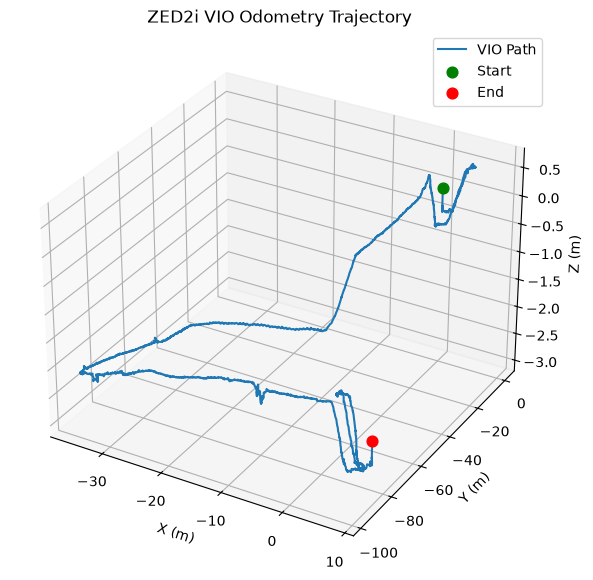

In [61]:
import matplotlib.pyplot as plt

# Load Zarr root directory
root = zarr.open('../../../zed2i_vio_map', mode='r')

# Extract position arrays (N, 3)
pos = root['pose_pos'][:]
timestamps = root['timestamp'][:]

# Plot 3D Trajectory
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(pos[:, 0], pos[:, 1], -pos[:, 2], label='VIO Path', color='tab:blue', linewidth=1.5)
ax.scatter(pos[0, 0], pos[0, 1], -pos[0, 2], color='green', s=60, label='Start')
ax.scatter(pos[-1, 0], pos[-1, 1], -pos[-1, 2], color='red', s=60, label='End')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('ZED2i VIO Odometry Trajectory')
ax.legend()
plt.grid(True)
plt.show()

In [62]:
from utils.BEV_helper_functions import build_pcd, generate_bev_from_o3d,ranges
def frame_id(path):
    m = re.search(r'(\d+)', os.path.basename(path))
    return int(m.group(1)) if m else 0

DEPTH = "../../../zed2i_depth_image/"
RGB = "../../../zed2i_right_images/"  

rgb_files = sorted(glob.glob(os.path.join(RGB, "*.jpeg")), key=frame_id)
depth_files = sorted(glob.glob(os.path.join(DEPTH, "*.png")), key=frame_id)

X_RANGE, Y_RANGE = ranges()

In [ ]:
import numpy as np
import zarr
from scipy.spatial.transform import Rotation, Slerp


# ----------------------------------------------------------------------------
# 1. Timestamp alignment: image timestamps -> interpolated VIO pose
# ----------------------------------------------------------------------------

def align_poses_to_images(vio_timestamps, pos, orien, cov, image_timestamps):
    vio_timestamps = np.asarray(vio_timestamps)
    image_timestamps = np.asarray(image_timestamps)

    idx_hi = np.searchsorted(vio_timestamps, image_timestamps, side='left')
    idx_hi = np.clip(idx_hi, 1, len(vio_timestamps) - 1)
    idx_lo = idx_hi - 1

    t_lo = vio_timestamps[idx_lo]
    t_hi = vio_timestamps[idx_hi]
    span = np.clip(t_hi - t_lo, 1e-9, None)
    alpha = np.clip((image_timestamps - t_lo) / span, 0.0, 1.0)

    # Linear interpolation for positions
    pos_i = pos[idx_lo] + alpha[:, None] * (pos[idx_hi] - pos[idx_lo])

    # Single vectorized Slerp pass over full VIO sequence
    valid_ts = np.clip(image_timestamps, vio_timestamps[0], vio_timestamps[-1])
    key_rots = Rotation.from_quat(orien)
    slerp = Slerp(vio_timestamps, key_rots)
    quat_i = slerp(valid_ts).as_quat()

    # Pick nearer sample covariance as confidence proxy
    nearer = np.where(alpha < 0.5, idx_lo, idx_hi)
    cov_i = cov[nearer]

    valid = (image_timestamps >= vio_timestamps[0]) & (image_timestamps <= vio_timestamps[-1])
    return pos_i, quat_i, cov_i, valid


# ----------------------------------------------------------------------------
# 2. Global grid container with density-weighted running-mean fusion
# ----------------------------------------------------------------------------

class GlobalBEVMap:
    def __init__(self, bounds_x, bounds_y, cell_size, channels=('z_mean', 'z_min', 'z_max', 'rgb'),
                 w_max=50.0):
        self.x0, self.x1 = bounds_x
        self.y0, self.y1 = bounds_y
        self.cell_size = cell_size
        self.w_max = w_max

        self.nx = int(np.ceil((self.x1 - self.x0) / cell_size))
        self.ny = int(np.ceil((self.y1 - self.y0) / cell_size))

        self.channels = channels
        has_rgb = 'rgb' in channels
        scalar_channels = [c for c in channels if c != 'rgb']

        self.weight = np.zeros((self.nx, self.ny), dtype=np.float32)
        self.last_seen = np.full((self.nx, self.ny), -1, dtype=np.int32)

        self.scalar = {c: np.full((self.nx, self.ny), np.nan, dtype=np.float32)
                        for c in scalar_channels}
        self.rgb = np.full((self.nx, self.ny, 3), np.nan, dtype=np.float32) if has_rgb else None

    def world_to_index(self, x, y):
        ix = np.floor((x - self.x0) / self.cell_size).astype(np.int64)
        iy = np.floor((y - self.y0) / self.cell_size).astype(np.int64)
        in_bounds = (ix >= 0) & (ix < self.nx) & (iy >= 0) & (iy < self.ny)
        return ix, iy, in_bounds

    def fuse_frame(self, local_cell_x, local_cell_y, local_values, frame_weight, frame_index):
        ix, iy, in_bounds = self.world_to_index(local_cell_x, local_cell_y)
        if not np.any(in_bounds):
            return

        ix, iy = ix[in_bounds], iy[in_bounds]
        lin = ix * self.ny + iy

        # Find unique global cells observed in this frame
        unique_lin, inverse_idx = np.unique(lin, return_inverse=True)
        num_unique = len(unique_lin)

        flat_w = self.weight.reshape(-1)
        flat_ls = self.last_seen.reshape(-1)

        old_w_unique = flat_w[unique_lin]
        
        # Fuse channels first using old cell weights
        for ch, vals in local_values.items():
            vals = vals[in_bounds]
            is_rgb = (ch == 'rgb')
            valid_mask = ~np.isnan(vals).any(axis=-1) if is_rgb else ~np.isnan(vals)

            if not np.any(valid_mask):
                continue

            inv_v = inverse_idx[valid_mask]
            vals_v = vals[valid_mask]

            counts = np.bincount(inv_v, minlength=num_unique)
            has_obs = counts > 0
            u_lin_ch = unique_lin[has_obs]
            u_old_w = old_w_unique[has_obs]
            cnt_safe = np.maximum(counts[has_obs], 1)

            if is_rgb:
                sums_r = np.bincount(inv_v, weights=vals_v[:, 0], minlength=num_unique)
                sums_g = np.bincount(inv_v, weights=vals_v[:, 1], minlength=num_unique)
                sums_b = np.bincount(inv_v, weights=vals_v[:, 2], minlength=num_unique)
                avg_vals = np.stack([sums_r[has_obs]/cnt_safe, sums_g[has_obs]/cnt_safe, sums_b[has_obs]/cnt_safe], axis=1)
            else:
                sums = np.bincount(inv_v, weights=vals_v, minlength=num_unique)
                avg_vals = sums[has_obs] / cnt_safe

            self._fuse_channel_unique(ch, u_lin_ch, avg_vals, frame_weight, u_old_w)

        # Increment weight once per unique observed cell
        new_w_unique = np.clip(old_w_unique + frame_weight, 0, self.w_max)
        flat_w[unique_lin] = new_w_unique
        flat_ls[unique_lin] = frame_index
        self.weight = flat_w.reshape(self.nx, self.ny)
        self.last_seen = flat_ls.reshape(self.nx, self.ny)

    def _fuse_channel_unique(self, ch, lin_idx, avg_vals, frame_weight, old_w):
        is_rgb = (ch == 'rgb')
        arr = self.rgb if is_rgb else self.scalar[ch]
        flat = arr.reshape(-1, 3) if is_rgb else arr.reshape(-1)

        old = flat[lin_idx]
        no_prior = np.isnan(old).any(axis=-1) if is_rgb else np.isnan(old)

        new_w = old_w + frame_weight
        new_w_safe = np.where(new_w <= 0, 1.0, new_w)

        if is_rgb:
            blended = (np.where(no_prior[:, None], 0, old) * old_w[:, None] + avg_vals * frame_weight) / new_w_safe[:, None]
            flat[lin_idx] = np.where(no_prior[:, None], avg_vals, blended)
            self.rgb = flat.reshape(self.nx, self.ny, 3)
        else:
            blended = (np.where(no_prior, 0, old) * old_w + avg_vals * frame_weight) / new_w_safe
            flat[lin_idx] = np.where(no_prior, avg_vals, blended)
            self.scalar[ch] = flat.reshape(self.nx, self.ny)


# ----------------------------------------------------------------------------
# 3. Per-frame local -> global transform of occupied BEV cells
# ----------------------------------------------------------------------------

def local_bev_to_world_cells(bev_map, x_range, y_range, pos_w, quat_w):
    C, H, W = bev_map.shape
    
    # Note: If generate_bev_from_o3d puts row 0 at x_max, reverse xs:
    # xs = np.linspace(x_range[1], x_range[0], H, endpoint=False) - (x_range[1]-x_range[0])/H/2
    xs = np.linspace(x_range[0], x_range[1], H, endpoint=False) + (x_range[1]-x_range[0])/H/2
    ys = np.linspace(y_range[0], y_range[1], W, endpoint=False) + (y_range[1]-y_range[0])/W/2
    gx, gy = np.meshgrid(xs, ys, indexing='ij')

    local_xy = np.stack([gx.ravel(), gy.ravel(), np.zeros(gx.size)], axis=1)

    R = Rotation.from_quat(quat_w)
    world_xyz = R.apply(local_xy) + pos_w
    world_x, world_y = world_xyz[:, 0], world_xyz[:, 1]

    values = {}
    channel_names = ['z_mean', 'z_min', 'z_max']
    for i, name in enumerate(channel_names):
        if i < C:
            values[name] = bev_map[i].ravel()
    if C >= 9:
        values['rgb'] = np.transpose(bev_map[6:9], (1, 2, 0)).reshape(-1, 3)

    return world_x, world_y, values


# ----------------------------------------------------------------------------
# 4. Driver
# ----------------------------------------------------------------------------

def build_global_map(rgb_files, depth_files, image_timestamps,
                      vio_timestamps, pos, orien, cov,
                      build_pcd, generate_bev_from_o3d,
                      x_range, y_range, cell_size, w_max=50.0,
                      num_frames=None):

    pos_i, quat_i, cov_i, valid = align_poses_to_images(
        vio_timestamps, pos, orien, cov, image_timestamps)

    valid_idx = np.flatnonzero(valid)
    if len(valid_idx) == 0:
        raise ValueError("No image timestamps fall within the VIO time range.")

    if num_frames is not None:
        valid_idx = valid_idx[num_frames[0]:num_frames[-1]]

    pad = max(abs(x_range[0]), abs(x_range[1]), abs(y_range[0]), abs(y_range[1])) + 2 * cell_size
    xs_all, ys_all = pos_i[valid_idx, 0], pos_i[valid_idx, 1]
    bounds_x = (xs_all.min() - pad, xs_all.max() + pad)
    bounds_y = (ys_all.min() - pad, ys_all.max() + pad)

    gmap = GlobalBEVMap(bounds_x, bounds_y, cell_size, w_max=w_max)

    pos_cov_trace = np.einsum('nii->n', cov_i[:, :3, :3])
    frame_weights = 1.0 / np.clip(pos_cov_trace, 1e-6, None)
    frame_weights = frame_weights / np.median(frame_weights[valid_idx])

    total = len(valid_idx)
    log_every = max(1, total // 20)

    for k, i in enumerate(valid_idx):
        pcd = build_pcd(rgb_files[i], depth_files[i])
        bev = generate_bev_from_o3d(pcd, x_range=x_range, y_range=y_range)

        wx, wy, values = local_bev_to_world_cells(
            bev, x_range, y_range, pos_i[i], quat_i[i])

        gmap.fuse_frame(wx, wy, values, frame_weight=float(frame_weights[i]), frame_index=k)

        if (k + 1) % log_every == 0 or (k + 1) == total:
            pct = 100.0 * (k + 1) / total
            print(f"[global BEV fusion] {k + 1}/{total} frames ({pct:.1f}%)")

    return gmap

vio_root = zarr.open('../../../zed2i_vio_map', mode='r')
pos = vio_root['pose_pos'][:]
cov = vio_root['pose_cov'][:]
vio_timestamps = vio_root['timestamp'][:]

# Fix quaternion order from [w, x, y, z] to [x, y, z, w]
orien_raw = vio_root['pose_orien'][:]
orien = orien_raw[:, [1, 2, 3, 0]]

img_root = zarr.open('../../../zed2i_right_images_data', mode='r')
image_timestamps = img_root['timestamp'][:]

# Verify fix: roll should now be near 0 degrees when upright
sample_euler = Rotation.from_quat(orien[0]).as_euler('xyz', degrees=True)
print(f"Sanity check - Frame 0 Euler (roll, pitch, yaw): {sample_euler}")

Sanity check - Frame 0 Euler (roll, pitch, yaw): [  0.18788321 -11.1513675   -0.95980439]


In [ ]:
CELL_SIZE=0.05
gmap = build_global_map(rgb_files, depth_files, image_timestamps,
                         vio_timestamps, pos, orien, cov,
                         build_pcd, generate_bev_from_o3d,
                         x_range=X_RANGE, y_range=Y_RANGE, cell_size=CELL_SIZE,num_frames=500)

[global BEV fusion] 25/500 frames (5.0%)
[global BEV fusion] 50/500 frames (10.0%)
[global BEV fusion] 75/500 frames (15.0%)
[global BEV fusion] 100/500 frames (20.0%)
[global BEV fusion] 125/500 frames (25.0%)
[global BEV fusion] 150/500 frames (30.0%)
[global BEV fusion] 175/500 frames (35.0%)
[global BEV fusion] 200/500 frames (40.0%)
[global BEV fusion] 225/500 frames (45.0%)
[global BEV fusion] 250/500 frames (50.0%)
[global BEV fusion] 275/500 frames (55.0%)
[global BEV fusion] 300/500 frames (60.0%)
[global BEV fusion] 325/500 frames (65.0%)
[global BEV fusion] 350/500 frames (70.0%)
[global BEV fusion] 375/500 frames (75.0%)
[global BEV fusion] 400/500 frames (80.0%)
[global BEV fusion] 425/500 frames (85.0%)
[global BEV fusion] 450/500 frames (90.0%)
[global BEV fusion] 475/500 frames (95.0%)
[global BEV fusion] 500/500 frames (100.0%)


TypeError: cannot unpack non-iterable GlobalBEVMap object

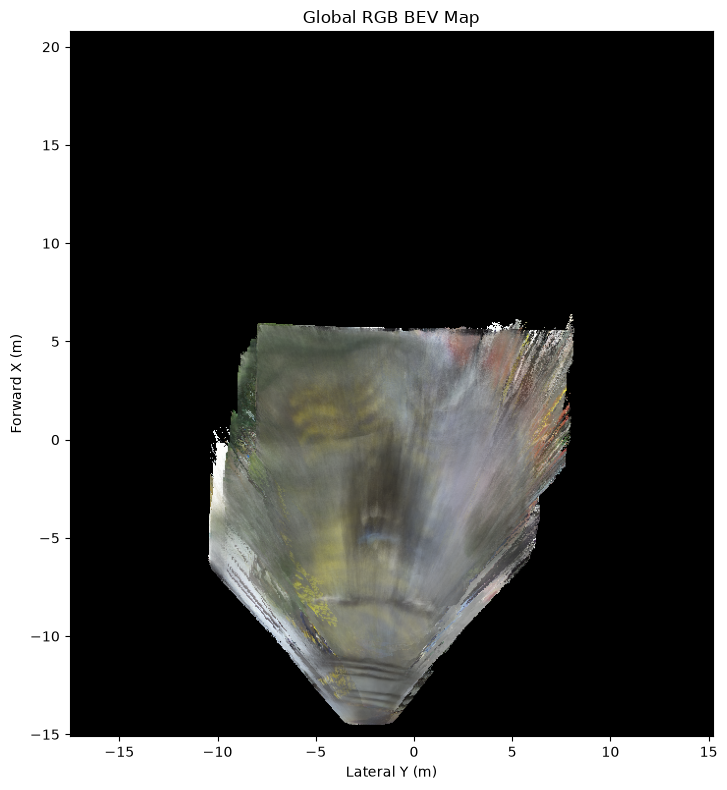

In [105]:
import matplotlib.pyplot as plt
import numpy as np

rgb_vis = np.nan_to_num(gmap.rgb)
if np.nanmax(rgb_vis) > 1.0:
    rgb_vis = rgb_vis / 255.0

# gmap.rgb is (nx, ny, 3) with x=forward, y=lateral -> origin='lower' + this extent
# keeps it consistent with your local BEV plot convention
extent = [gmap.y0, gmap.y1, gmap.x0, gmap.x1]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_vis, extent=extent)
ax.set_xlabel("Lateral Y (m)")
ax.set_ylabel("Forward X (m)")
ax.set_title("Global RGB BEV Map")


plt.tight_layout()
plt.show()

In [90]:
print(Rotation.from_quat(orien[0]).as_euler('xyz', degrees=True))

[-179.04019561   11.1513675     0.18788321]
